# Item 4: Similaridade de palavras com modelos de linguagem

Testamos a similaridade dos pares de palavras dos **dois datasets** com 3 tipos de modelo:

1. **Estático:** spaCy `pt_core_news_lg` (um vetor fixo por palavra)
2. **Transformer:** BERT, com BERTimbau (`neuralmind/bert-base-portuguese-cased`) e `bert-base-uncased`
3. **LLM:** Claude (Opus 5.5), anotando em uma sessão separada; o Gemini (API gratuita) ficou como opcional

Para spaCy e BERT a nota do modelo é o **cosseno** entre os vetores das duas palavras. O LLM recebe a
mesma escala e as mesmas instruções que os anotadores usaram e devolve uma nota.

A comparação com as notas humanas usa principalmente a **correlação de Spearman**: ela só olha a ordem dos
pares, então não importa que o cosseno vá de -1 a 1, o nosso dataset vá de 1 a 5 e o da aula de 0 a 1.

## Como rodar

```
uv add spacy transformers torch google-genai pandas scipy matplotlib
uv pip install https://github.com/explosion/spacy-models/releases/download/pt_core_news_lg-3.8.0/pt_core_news_lg-3.8.0-py3-none-any.whl
```

Para o Gemini, crie uma chave gratuita em https://aistudio.google.com/apikey e coloque no arquivo
`.env` desta pasta, na linha `GEMINI_API_KEY=...` (o `.env` é ignorado pelo git; não coloque a chave no notebook). As respostas do
Gemini ficam salvas em `cache_gemini/`, então rodar o notebook de novo não gasta a cota gratuita.

## 0. Dados

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

PASTA = Path.cwd()  # o notebook roda dentro de similaridade/topico_4/
if not (PASTA / "dataset_aula.csv").exists():
    PASTA = Path("similaridade/topico_4")  # rodando a partir da raiz do repositório

In [2]:
# Nosso dataset: 100 pares, escala Likert 1 a 5 (Gabriela = a1, Renato = a2)
nosso = pd.read_csv(PASTA.parent / "similaridade_final.csv")
nosso = nosso.rename(columns={"similaridade_a1": "a1", "similaridade_a2": "a2", "similaridade_media": "humano"})

# Dataset da aula: 80 pares, escala de 0 a 1 (CSV do Excel: separador ";" e vírgula decimal)
aula = pd.read_csv(PASTA / "dataset_aula.csv", sep=";", decimal=",", encoding="utf-8-sig", usecols=range(6))
aula.columns = ["id", "palavra_1", "palavra_2", "a1", "a2", "humano"]
aula = aula.drop(columns="id")

DATASETS = {"nosso": nosso, "aula": aula}
for nome, df in DATASETS.items():
    # tudo em minúsculas: o dataset da aula vem com a primeira letra maiúscula
    df["palavra_1"] = df["palavra_1"].str.strip().str.lower()
    df["palavra_2"] = df["palavra_2"].str.strip().str.lower()
    print(f"{nome}: {len(df)} pares, notas humanas de {df['humano'].min()} a {df['humano'].max()}")

aula.head()

nosso: 100 pares, notas humanas de 1.0 a 4.0
aula: 80 pares, notas humanas de 0.0 a 1.0


,palavra_1,palavra_2,a1,a2,humano
0,compilar,interpretar,0.75,0.75,0.750
1,executar,rodar,1.00,1.00,1.000
2,inicializar,instanciar,0.75,0.25,0.500
3,declarar,definir,0.75,0.50,0.625
4,atribuir,setar,1.00,0.00,0.500


In [3]:
# Referência: quanto os dois anotadores concordam entre si.
# Um modelo dificilmente vai concordar com a média dos humanos muito mais do que eles concordam entre si.
for nome, df in DATASETS.items():
    print(f"{nome}: Spearman a1 x a2 = {spearmanr(df['a1'], df['a2']).statistic:.3f}")

nosso: Spearman a1 x a2 = 0.265
aula: Spearman a1 x a2 = 0.755


In [4]:
# Aqui ficam as notas de cada modelo: notas[dataset][modelo] = lista com uma nota por par
notas = {nome: {} for nome in DATASETS}


def avaliar(nome_modelo, dataset):
    # correlação das notas do modelo com a média humana e com cada anotador
    df = DATASETS[dataset]
    x = pd.Series(notas[dataset][nome_modelo], index=df.index)
    ok = x.notna()  # pares sem nota (ex.: palavra sem vetor) ficam de fora
    return {
        "dataset": dataset,
        "modelo": nome_modelo,
        "pares": int(ok.sum()),
        "spearman_media": spearmanr(x[ok], df["humano"][ok]).statistic,
        "pearson_media": pearsonr(x[ok], df["humano"][ok]).statistic,
        "spearman_a1": spearmanr(x[ok], df["a1"][ok]).statistic,
        "spearman_a2": spearmanr(x[ok], df["a2"][ok]).statistic,
    }

## 1. Modelo estático: spaCy `pt_core_news_lg`

Cada palavra tem um único vetor de 300 dimensões, aprendido pela co-ocorrência das palavras em um corpus
grande. O vetor não depende do contexto. Para termos com mais de uma palavra (ex.: "banco de dados"), o
spaCy usa a média dos vetores.

In [5]:
import spacy

nlp = spacy.load("pt_core_news_lg")


def similaridade_spacy(p1, p2):
    d1, d2 = nlp(p1), nlp(p2)
    if not d1.has_vector or not d2.has_vector:
        return np.nan  # palavra fora do vocabulário: sem vetor, não dá para comparar
    return d1.similarity(d2)  # cosseno entre os vetores


for nome, df in DATASETS.items():
    notas[nome]["spaCy"] = [similaridade_spacy(a, b) for a, b in zip(df["palavra_1"], df["palavra_2"])]
    sem_vetor = [f"{a}-{b}" for a, b, n in zip(df["palavra_1"], df["palavra_2"], notas[nome]["spaCy"]) if np.isnan(n)]
    print(f"{nome}: {len(sem_vetor)} pares sem vetor {sem_vetor}")

nosso: 0 pares sem vetor []


aula: 5 pares sem vetor ['parsear-analisar', 'liberar-desalocar', 'deployar-publicar', 'versionar-comitar', 'tokenizar-segmentar']


In [6]:
pd.DataFrame([avaliar("spaCy", d) for d in DATASETS]).round(3)

,dataset,modelo,pares,spearman_media,pearson_media,spearman_a1,spearman_a2
0,nosso,spaCy,100,0.173,0.181,0.336,0.122
1,aula,spaCy,75,-0.028,0.006,0.025,-0.073


## 2. Transformer: BERT

O BERT gera um vetor para cada token **dependendo do contexto**. Aqui a palavra entra sozinha (`[CLS]
palavra [SEP]`), sem frase em volta, e o vetor dela é a média dos vetores dos seus sub-tokens (sem `[CLS]`
e `[SEP]`). A nota é o cosseno entre os vetores das duas palavras.

Testamos dois modelos:
- **BERTimbau** (`neuralmind/bert-base-portuguese-cased`): treinado em português.
- **`bert-base-uncased`**: o sugerido no enunciado, treinado só em inglês. Ele quebra palavras em português
  em pedaços que não têm significado, então esperamos um resultado pior.

In [7]:
import torch
from transformers import AutoTokenizer, AutoModel

MODELOS_BERT = {"BERTimbau": "neuralmind/bert-base-portuguese-cased", "BERT (inglês)": "bert-base-uncased"}


def vetor_bert(palavra, tokenizador, modelo):
    entrada = tokenizador(palavra, return_tensors="pt")
    with torch.no_grad():  # não estamos treinando o BERT, só usando
        saida = modelo(**entrada).last_hidden_state[0]  # um vetor de 768 posições por token
    return saida[1:-1].mean(dim=0)  # média dos sub-tokens, sem [CLS] e [SEP]


for nome_curto, nome_modelo in MODELOS_BERT.items():
    tokenizador = AutoTokenizer.from_pretrained(nome_modelo)
    modelo = AutoModel.from_pretrained(nome_modelo)
    modelo.eval()
    print(nome_curto, "| exemplo de tokenização:", tokenizador.tokenize("criptografar"))

    for nome, df in DATASETS.items():
        vetores = {p: vetor_bert(p, tokenizador, modelo) for p in set(df["palavra_1"]) | set(df["palavra_2"])}
        notas[nome][nome_curto] = [torch.cosine_similarity(vetores[a], vetores[b], dim=0).item()
                                   for a, b in zip(df["palavra_1"], df["palavra_2"])]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTimbau | exemplo de tokenização: ['cripto', '##graf', '##ar']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT (inglês) | exemplo de tokenização: ['cr', '##ip', '##to', '##gra', '##far']


In [8]:
pd.DataFrame([avaliar(m, d) for m in MODELOS_BERT for d in DATASETS]).round(3)

,dataset,modelo,pares,spearman_media,pearson_media,spearman_a1,spearman_a2
0,nosso,BERTimbau,100,0.224,0.174,0.191,0.207
1,aula,BERTimbau,80,-0.012,0.008,0.047,-0.065
2,nosso,BERT (inglês),100,-0.039,-0.050,-0.008,-0.065
3,aula,BERT (inglês),80,-0.015,-0.014,0.040,-0.102


## 3. LLM

### 3.1 Claude

As notas do Claude foram dadas em uma **sessão separada** do Claude (Opus 5.5), usando o
prompt de `claude/PROMPT.md`. Essa sessão só podia ler `claude/entrada_nosso.csv` e
`claude/entrada_aula.csv`, que têm apenas os pares, sem as notas humanas. As instruções e as escalas são as
mesmas dadas aos anotadores. Ela escreveu as respostas em `claude/respostas_nosso.csv` e
`claude/respostas_aula.csv`, e o modelo e a data em `claude/MODELO.txt`.

Como as notas vieram de uma conversa e não de uma chamada de API no notebook, não dá para reproduzi-las
rodando o código: o resultado fica registrado nos arquivos.

In [9]:
PASTA_CLAUDE = PASTA / "claude"
print((PASTA_CLAUDE / "MODELO.txt").read_text(encoding="utf-8"))

ESCALA_VALIDA = {"nosso": {1, 2, 3, 4, 5}, "aula": {0, 0.25, 0.5, 0.75, 1}}

for nome, df in DATASETS.items():
    respostas = pd.read_csv(PASTA_CLAUDE / f"respostas_{nome}.csv")
    # confere se as respostas batem com os pares do dataset, na mesma ordem
    assert list(respostas["palavra_1"]) == list(df["palavra_1"]), f"{nome}: palavra_1 não bate"
    assert list(respostas["palavra_2"]) == list(df["palavra_2"]), f"{nome}: palavra_2 não bate"
    assert respostas["nota"].isin(ESCALA_VALIDA[nome]).all(), f"{nome}: nota fora da escala"
    notas[nome]["Claude"] = list(respostas["nota"])
    print(nome, "| distribuição das notas:", respostas["nota"].value_counts().sort_index().to_dict())

Modelo: Claude Opus 5.5 (claude-opus-5-5)
Data: 2026-10-05

nosso | distribuição das notas: {1: 70, 2: 23, 3: 6, 4: 1}
aula | distribuição das notas: {0.25: 5, 0.5: 26, 0.75: 35, 1.0: 14}


In [10]:
pd.DataFrame([avaliar("Claude", d) for d in DATASETS]).round(3)

,dataset,modelo,pares,spearman_media,pearson_media,spearman_a1,spearman_a2
0,nosso,Claude,100,0.531,0.571,0.502,0.460
1,aula,Claude,80,0.482,0.450,0.537,0.384


### 3.2 Gemini (opcional)

Também tentamos usar o Gemini pela API gratuita do Google AI Studio, com o mesmo prompt. Todos
os modelos gratuitos testados (3.8 Flash, 3.5 Flash e 3.1 Flash Lite) responderam **503 (sobrecarregado)**
para o pedido com todos os pares, então o Gemini ficou fora da comparação. O código continua aqui: para
tentar de novo, configurar `USAR_GEMINI = True`.

Cada dataset vai em **uma única chamada**, e a resposta fica salva em `cache_gemini/` (rodar de novo não gasta
a cota). Se um modelo de `MODELOS_GEMINI` estiver sobrecarregado, o notebook tenta o próximo. A chave fica no
arquivo `.env` desta pasta, na linha `GEMINI_API_KEY=...` (o `.env` é ignorado pelo git).

In [11]:
import time

from google import genai
from google.genai import errors, types
from pydantic import BaseModel

USAR_GEMINI = False  # a API gratuita só respondeu 503; True para tentar de novo

# em ordem de preferência: se um estiver sobrecarregado (erro 503), tenta o próximo
MODELOS_GEMINI = ["gemini-3.8-flash", "gemini-3.5-flash", "gemini-3.1-flash-lite"]
PASTA_CACHE_GEMINI = PASTA / "cache_gemini"
PASTA_CACHE_GEMINI.mkdir(exist_ok=True)

# a chave fica no arquivo .env desta pasta (ignorado pelo git), na linha GEMINI_API_KEY=...
arquivo_env = PASTA / ".env"
if "GEMINI_API_KEY" not in os.environ and arquivo_env.exists():
    for linha in arquivo_env.read_text(encoding="utf-8").splitlines():
        nome, _, valor = linha.partition("=")
        if nome.strip() == "GEMINI_API_KEY":
            os.environ["GEMINI_API_KEY"] = valor.strip().strip('"')

if USAR_GEMINI:
    cliente = genai.Client()  # lê a chave da variável de ambiente GEMINI_API_KEY
    # modelos disponíveis para a chave (útil se algum nome acima tiver sido descontinuado)
    print([m.name for m in cliente.models.list() if "flash" in m.name])

In [12]:
ESCALAS = {
    "nosso": '''Use a escala Likert de 1 a 5 (só números inteiros):
1 = Totalmente dissimilar (ou Muito diferente)
2 = Parcialmente dissimilar (ou Um pouco diferente)
3 = Neutro / Indiferente (Nem similar, nem dissimilar)
4 = Parcialmente similar (ou Um pouco parecido)
5 = Totalmente similar (ou Muito parecido)''',
    "aula": '''Use uma nota de 0 a 1, só com os valores 0, 0.25, 0.5, 0.75 ou 1:
0 = nada similar, 0.5 = similaridade intermediária, 1 = mesmo significado.''',
}


class Nota(BaseModel):
    id: int
    nota: float


def notas_gemini(dataset):
    arquivo = PASTA_CACHE_GEMINI / f"{dataset}.json"
    if arquivo.exists():
        salvo = json.loads(arquivo.read_text(encoding="utf-8"))
        print(f"Usando respostas salvas em {arquivo} (modelo {salvo['modelo']})")
        return salvo["notas"]

    df = DATASETS[dataset]
    pares = "\n".join(f"{i}: {a} | {b}" for i, (a, b) in enumerate(zip(df["palavra_1"], df["palavra_2"])))
    prompt = (
        "Você é um anotador de um dataset de similaridade semântica de palavras do domínio de "
        "Tecnologia da Informação. Para cada par abaixo, avalie o quanto as duas palavras são "
        "similares em significado.\n\n"
        f"{ESCALAS[dataset]}\n\n"
        "Responda com uma nota para cada id.\n\n"
        f"Pares (id: palavra_1 | palavra_2):\n{pares}"
    )
    resposta = None
    for tentativa in range(6):
        modelo = MODELOS_GEMINI[tentativa % len(MODELOS_GEMINI)]
        try:
            resposta = cliente.models.generate_content(
                model=modelo,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=0,  # sem aleatoriedade, para o resultado ser o mais estável possível
                    response_mime_type="application/json",
                    response_schema=list[Nota],
                ),
            )
            break
        except errors.ServerError as erro:  # 503: modelo sobrecarregado, espera e tenta de novo
            print(f"Tentativa {tentativa + 1} com {modelo} falhou ({erro.code}), esperando 20 s")
            time.sleep(20)
    if resposta is None:
        raise RuntimeError("o Gemini continua indisponível; rode a célula mais tarde")
    print(f"{dataset}: notas dadas pelo {modelo}")
    por_id = {n.id: n.nota for n in resposta.parsed}
    faltando = [i for i in range(len(df)) if i not in por_id]
    if faltando:
        raise ValueError(f"o Gemini não deu nota para os ids {faltando}; rode de novo")

    resultado = [por_id[i] for i in range(len(df))]
    arquivo.write_text(json.dumps({"modelo": modelo, "notas": resultado}), encoding="utf-8")
    return resultado


if USAR_GEMINI:
    for nome in DATASETS:
        try:
            notas[nome]["Gemini"] = notas_gemini(nome)
        except Exception as erro:
            print(f"{nome}: Gemini indisponível, fica fora da comparação ({erro})")
else:
    print("Gemini desligado (USAR_GEMINI = False)")

Gemini desligado (USAR_GEMINI = False)


In [13]:
pd.DataFrame([avaliar("Gemini", d) for d in DATASETS if "Gemini" in notas[d]]).round(3)

""


## 4. Comparação dos modelos

Tabela com todos os modelos nos dois datasets. A linha **Humanos (a1 x a2)** é a concordância entre os
próprios anotadores e serve de referência.

In [14]:
MODELOS = ["spaCy", *MODELOS_BERT, "Claude"]
if all("Gemini" in notas[d] for d in DATASETS):
    MODELOS.append("Gemini")

linhas = [avaliar(m, d) for d in DATASETS for m in MODELOS]
for d, df in DATASETS.items():
    linhas.append({"dataset": d, "modelo": "Humanos (a1 x a2)", "pares": len(df),
                   "spearman_media": np.nan, "pearson_media": np.nan,
                   "spearman_a1": 1.0, "spearman_a2": spearmanr(df["a1"], df["a2"]).statistic})
comparacao = pd.DataFrame(linhas).sort_values(["dataset", "spearman_media"], ascending=[True, False])
comparacao.to_csv(PASTA / "comparacao_modelos.csv", index=False)
comparacao.round(3)

,dataset,modelo,pares,spearman_media,pearson_media,spearman_a1,spearman_a2
7,aula,Claude,80,0.482,0.450,0.537,0.384
5,aula,BERTimbau,80,-0.012,0.008,0.047,-0.065
6,aula,BERT (inglês),80,-0.015,-0.014,0.040,-0.102
4,aula,spaCy,75,-0.028,0.006,0.025,-0.073
9,aula,Humanos (a1 x a2),80,NaN,NaN,1.000,0.755
3,nosso,Claude,100,0.531,0.571,0.502,0.460
1,nosso,BERTimbau,100,0.224,0.174,0.191,0.207
0,nosso,spaCy,100,0.173,0.181,0.336,0.122
2,nosso,BERT (inglês),100,-0.039,-0.050,-0.008,-0.065
8,nosso,Humanos (a1 x a2),100,NaN,NaN,1.000,0.265


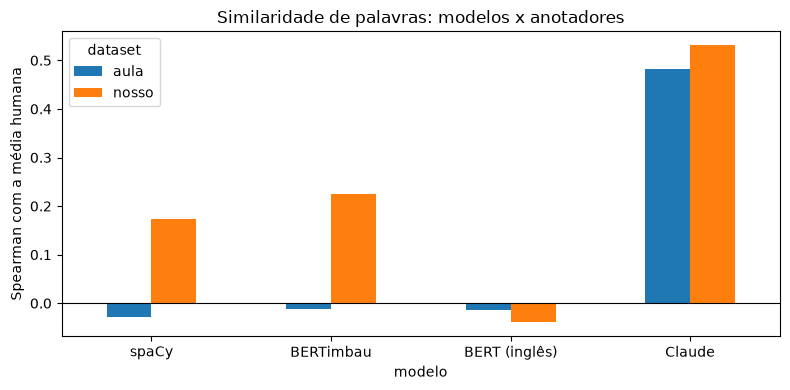

In [15]:
# Spearman de cada modelo com a média humana, por dataset
tabela = comparacao.dropna(subset=["spearman_media"]).pivot(index="modelo", columns="dataset", values="spearman_media")
ax = tabela.loc[MODELOS].plot.bar(figsize=(8, 4), rot=0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Spearman com a média humana")
ax.set_title("Similaridade de palavras: modelos x anotadores")
plt.tight_layout()
plt.savefig(PASTA / "comparacao_modelos.png", dpi=150)
plt.show()

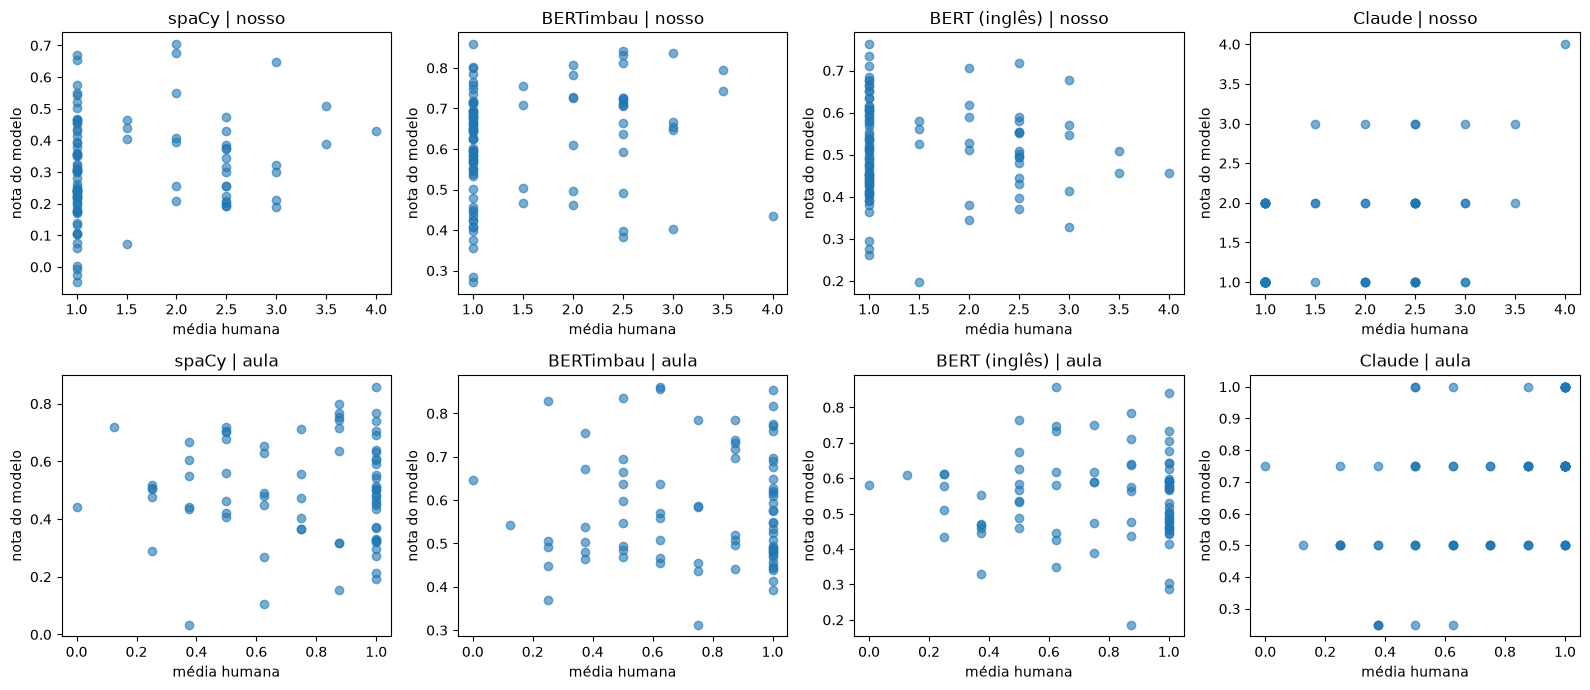

In [16]:
# Nota de cada modelo x média humana (cada ponto é um par)
fig, eixos = plt.subplots(len(DATASETS), len(MODELOS), figsize=(4 * len(MODELOS), 7))
for linha, (d, df) in enumerate(DATASETS.items()):
    for coluna, m in enumerate(MODELOS):
        ax = eixos[linha, coluna]
        ax.scatter(df["humano"], notas[d][m], alpha=0.6)
        ax.set_title(f"{m} | {d}")
        ax.set_xlabel("média humana")
        ax.set_ylabel("nota do modelo")
plt.tight_layout()
plt.savefig(PASTA / "dispersao_modelos.png", dpi=150)
plt.show()

### Onde os modelos mais discordam dos humanos

Como as escalas são diferentes, comparamos as **posições** (rank em percentil, de 0 a 1): um par que os
humanos acham dos mais similares e o modelo acha dos menos similares tem diferença perto de 1.

In [17]:
def maiores_divergencias(dataset, modelo, n=8):
    df = DATASETS[dataset][["palavra_1", "palavra_2", "humano"]].copy()
    df["modelo"] = notas[dataset][modelo]
    df["diferenca"] = df["modelo"].rank(pct=True) - df["humano"].rank(pct=True)
    # diferença > 0: o modelo acha mais similar que os humanos; < 0: menos similar
    return df.reindex(df["diferenca"].abs().sort_values(ascending=False).index).head(n).round(3)


for d in DATASETS:
    for m in MODELOS:
        print(f"\n===== {m} | dataset {d} =====")
        display(maiores_divergencias(d, m))


===== spaCy | dataset nosso =====


,palavra_1,palavra_2,humano,modelo,diferenca
19,código,proteção,3.0,0.191,-0.770
42,host,comando,3.0,0.210,-0.680
7,senha,vulnerabilidade,2.5,0.191,-0.660
27,ataque,dado,2.5,0.192,-0.650
51,operacional,utilização,1.0,0.669,0.645
56,organização,implementar,1.0,0.654,0.635
35,tarefa,programa,2.5,0.202,-0.630
79,fluxo,pessoa,1.5,0.073,-0.625



===== BERTimbau | dataset nosso =====


,palavra_1,palavra_2,humano,modelo,diferenca
47,exigir,requisito,4.0,0.435,-0.870
42,host,comando,3.0,0.403,-0.870
7,senha,vulnerabilidade,2.5,0.383,-0.800
53,componente,acessar,2.5,0.398,-0.780
21,protocolo,incluir,1.0,0.859,0.665
16,modelo,autenticação,2.5,0.492,-0.640
52,armazenamento,conjunto,1.0,0.802,0.605
86,algoritmo,elemento,1.0,0.799,0.595



===== BERT (inglês) | dataset nosso =====


...

,palavra_1,palavra_2,humano,modelo,diferenca
77,hardware,componente,0.250,0.830,0.888
41,rotular,classificar,1.000,0.392,-0.750
63,variável,constante,0.500,0.836,0.738
29,deployar,publicar,1.000,0.413,-0.737
59,índice,chave,0.375,0.755,0.731
72,interface,api,1.000,0.438,-0.712
47,conectar,vincular,0.000,0.646,0.700
66,script,programa,1.000,0.442,-0.688



===== BERT (inglês) | dataset aula =====


,palavra_1,palavra_2,humano,modelo,diferenca
10,compactar,comprimir,1.000,0.288,-0.762
70,servidor,host,1.000,0.304,-0.750
2,inicializar,instanciar,0.500,0.765,0.738
31,sincronizar,replicar,0.125,0.608,0.700
52,campo,atributo,1.000,0.414,-0.700
54,banco de dados,repositório,0.250,0.612,0.688
77,hardware,componente,0.250,0.612,0.675
25,sobrescrever,sobrecarregar,0.625,0.858,0.669



===== Claude | dataset aula =====


,palavra_1,palavra_2,humano,modelo,diferenca
4,atribuir,setar,0.500,1.00,0.694
12,persistir,salvar,0.500,1.00,0.694
47,conectar,vincular,0.000,0.75,0.600
51,registro,tupla,0.625,1.00,0.587
30,versionar,comitar,1.000,0.50,-0.556
44,exportar,extrair,1.000,0.50,-0.556
75,rede,conexão,1.000,0.50,-0.556
74,memória,armazenamento,1.000,0.50,-0.556


## 5. Análise

### 5.1 Resultados

Correlação de Spearman entre a nota de cada modelo e a média dos dois anotadores (entre parênteses, o valor-p):

| modelo | nosso dataset (100 pares) | dataset da aula (80 pares) |
|---|:-:|:-:|
| **Claude (Opus 5.5)** | **0,53** (p < 0,001) | **0,48** (p < 0,001) |
| BERTimbau | 0,22 (p = 0,03) | −0,01 (p = 0,92) |
| spaCy `pt_core_news_lg` | 0,17 (p = 0,09) | −0,03 (p = 0,81), 75 pares |
| `bert-base-uncased` | −0,04 (p = 0,70) | −0,01 (p = 0,90) |
| *humanos (a1 x a2)* | *0,27* | *0,76* |

A ordem é a mesma nos dois datasets: **Claude > BERTimbau ≈ spaCy > BERT em inglês**. Só o Claude tem uma
correlação clara com os humanos nos dois. No dataset da aula, os três modelos de vetores ficam em zero.

### 5.2 A referência humana

Os dois datasets são bem diferentes como referência:

- **Dataset da aula:** os anotadores concordam bastante (Spearman 0,76). Os pares foram escolhidos por serem
  próximos (sinônimos, quase sinônimos e conceitos vizinhos), e a média humana é alta (0,76 em uma escala de
  0 a 1). O desafio aqui é **separar "igual" de "parecido"**, e não "parecido" de "sem relação".
- **Nosso dataset:** os pares foram sorteados entre as 200 palavras mais frequentes do corpus, então quase
  todos não têm relação (média humana 1,5 de 5). Os anotadores concordam pouco (0,27) porque usaram critérios
  diferentes: a Gabriela anotou **similaridade de significado** e o Renato anotou **relação entre as
  palavras** (ex.: código – proteção recebeu 1 e 5). A média dos dois mistura os dois critérios, então os
  resultados neste dataset são menos confiáveis.

### 5.3 spaCy (modelo estático)

- No nosso dataset a correlação é fraca (0,17) e não chega a ser significativa. Ela é maior com a Gabriela
  (0,34) que com o Renato (0,12).
- Os vetores do spaCy foram treinados em texto geral da web, não em textos de TI. Pares que só são
  próximos dentro da área ficam com cosseno baixo, como código – proteção (0,19) e host – comando (0,21).
  Já palavras abstratas e frequentes ficam próximas sem ter o mesmo sentido, como operacional – utilização
  (0,67) e organização – implementar (0,65).
- No dataset da aula o problema são os **anglicismos e termos técnicos**: thread – fluxo, iteração – loop e
  kernel – núcleo são sinônimos para os humanos, mas ficam com cosseno de 0,19 a 0,30. Em texto geral em
  português, esses termos em inglês provavelmente aparecem pouco e em outros contextos. Cinco palavras nem têm vetor (parsear,
  desalocar, deployar, versionar, tokenizar).
- O cosseno mede **co-ocorrência**: verbos que aparecem nos mesmos textos ficam próximos mesmo sem serem
  sinônimos, como sincronizar – replicar (0,72) e empilhar – enfileirar (0,72).
- O spaCy separa os dois datasets como um todo (cosseno médio de 0,31 nos pares sorteados e de 0,50 nos pares
  da aula). Mas ele não consegue ordenar os pares **dentro** do dataset da aula, que é o que a tarefa pede.

### 5.4 BERT (transformer)

- O **BERTimbau** é o melhor modelo de vetores no nosso dataset (0,22), mas fica em zero no dataset da aula.
- Os cossenos ficam todos em uma faixa estreita e alta: de 0,27 a 0,86 nos pares sorteados, com média de
  0,62. Essa média é **maior** que a dos pares da aula (0,58), que foram escolhidos por serem similares. Esse
  é o efeito de **anisotropia** dos embeddings do BERT: todos os vetores apontam mais ou menos para a mesma
  direção, então o cosseno diz pouco sobre o significado.
- Erros típicos: protocolo – incluir (0,86) e armazenamento – conjunto (0,80) ficam quase iguais, enquanto
  exigir – requisito fica com 0,44. No dataset da aula, hardware – componente (0,83) e variável – constante
  (0,84) ficam acima de rotular – classificar (0,39) e deployar – publicar (0,41).
- A causa principal é usar o BERT **fora do contexto**. Ele foi treinado para representar palavras dentro de
  frases. Com a palavra sozinha (`[CLS] palavra [SEP]`), o vetor reflete mais a forma da palavra e os seus
  sub-tokens do que o sentido.
- O **`bert-base-uncased`** fica em zero nos dois datasets. Ele foi treinado só em inglês e quebra as
  palavras em português em pedaços sem sentido ("criptografar" vira `cr ##ip ##to ##gra ##far`, enquanto o
  BERTimbau gera `cripto ##graf ##ar`). Isso mostra que o idioma do modelo importa mais do que a arquitetura.

### 5.5 Claude (LLM)

- É o único modelo que funciona nos dois datasets (0,53 e 0,48, ambos com p < 0,001). O LLM recebe a
  **instrução** do que é "similar" e a mesma escala dos anotadores. Os modelos de vetores não têm como saber
  qual critério usar: só calculam uma distância.
- No nosso dataset o Claude seguiu o critério de **similaridade de significado**: deu 1 para código –
  proteção e host – comando, que o Renato, anotando relação, avaliou com 5. Isso explica as maiores
  divergências dele com a média.
- No dataset da aula ele é **mais rigoroso** que os humanos com o que é "mesmo significado": deu 0,5 para
  versionar – comitar, rede – conexão e memória – armazenamento, que os humanos avaliaram com 1. Ele também
  deu 1 para pares em que os próprios humanos discordaram, como atribuir – setar (1 e 0) e persistir – salvar.
- Mesmo sendo o melhor, ainda está longe da concordância entre os humanos no dataset da aula (0,48 contra
  0,76).

### 5.6 Conclusão

Medir similaridade de palavras com **cosseno entre vetores** funciona mal nos dois tipos de modelo testados.
Os vetores estáticos medem co-ocorrência em texto geral, e o BERT sem contexto gera vetores pouco
informativos. Os dois falham principalmente quando é preciso **separar graus de similaridade** entre pares
que já são próximos, como no dataset da aula. O LLM consegue fazer isso porque recebe o critério da
anotação em linguagem natural, e foi o único com correlação clara nos dois datasets.

### 5.7 Limitações

- **Reprodutibilidade:** as notas do Claude vieram de uma única sessão (registrada em `claude/`) e podem
  mudar entre conversas ou versões do modelo.
- **Gemini:** a API gratuita respondeu 503 (sobrecarregado) no dia dos testes, então ficou fora da comparação.
- **Empates:** as notas do Claude e dos humanos são discretas (70 dos 100 pares do nosso dataset receberam 1
  do Claude), o que limita o Spearman.
- **Tamanho:** com 80 a 100 pares, diferenças pequenas (como entre spaCy e BERTimbau no nosso dataset) não são
  significativas.